# **Laboratorio 6: Diseño y Aplicación de Filtros Digitales para Señales Biomédicas**
---

En este cuaderno, se abordará el proceso de diseño, aplicación y evaluación de filtros digitales para el procesamiento de señales biomédicas reales. Se utilizarán dos tipos de señales adquiridas previamente con el dispositivo BITALINO:

1. **Electromiografía de Superficie (sEMG):** Registrada durante contracciones musculares del bíceps y tríceps.

2. **Electrocardiografía (ECG):** Registrada en reposo y durante la recuperación post-ejercicio.

El objetivo principal es eliminar el ruido y los artefactos inherenets a cada señal para obtener una representación fidedigna de la actividad fisiológica. Para ello, se seguirá la siguiente metodología:

- **Carga y Visualización de Datos Crudos:** Se cargarán las señales sin procesar y se convertirán a unidades físicas (mV) para establecer una línea base.
- **Diseño de Filtros:** Se utilizará la herramienta `pyfdax` para diseñar un conjunto de filtros FIR e IIR con características específicas para cada tipo de señal.
- **Aplicación y Comparación:** Cada filtro se aplicará a la señal correspondiente y se evaluará su rendimiento de forma visual (domieno del tiempo y frecuencia) y cuantitativa.
- **Selección del Filtro Óptimo:** Se calculará la Relación Señal-Ruido (SNR) para cada caso y se generará una tabla comparativa para justificar la elección del filtro más adecuado para cada aplicación, priorizando tanto la limpieza de la señal como la preservación de su mofología característica.

## 1) Configuración inicial y carga de archvos
---

Es importante poder definir bien las rutas y funciones de carga y conversión de las señales registradas como valores de ADC a la unidad correcta para cada ganancia respectiva al sensor, en este caso serían (mV), tomando las referencias de los manuales de uso del kit BiTalino [1,2]

In [1]:
# Como primer paso importamos las liberías necesarias para el notebook
# Incluyendo tanto librerías para el análisis numérico, manipulación de datos, procesamiento señales y visualización

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch, freqz, filtfilt, sosfreqz, tf2sos
import os

# Configuramos que los gráficos se muestren directamente en el notebook
%matplotlib inline

# Configuramos el estilo para una mejor visualización de los gráficos
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (15,5)
plt.rcParams['font.size'] = 12

In [2]:
# Definición de rutas y constantes

# 1. Ruas de los archivos a las señales
# -------------------------------------
# Para el cuaderno, las rutas a los archivos se encuentran en Laboratorios/Laboratorio 6 - Filtros/

PATH_EMG = 'Señales_procesar/EMG/'
PATH_ECG = 'Señales_procesar/ECG/'

# Construimos las rutas completas a los archivos
ARCHIVOS = {
    'EMG_Biceps': os.path.join(PATH_EMG, 'biceps_maximo.txt'),
    'EMG_Triceps': os.path.join(PATH_EMG, 'triceps_maximo.txt'),
    'ECG_Reposo': os.path.join(PATH_ECG, 'derivacion_1_actividad_fisica.txt'),
    'ECG_PostEjercicio': os.path.join(PATH_ECG, 'derivacion_1_reposo.txt')
}

# Verificamos que los archivos existan en las rutas especificadas
for archivo in ARCHIVOS:
    if not os.path.exists(ARCHIVOS[archivo]):
        print(f'Advertencia: El archivo {ARCHIVOS[archivo]} no se encuentra en la ruta especificada.')  
    else:
        print(f'El archivo {ARCHIVOS[archivo]} se encuentra correctamente.')

# 2. Constantes del bitalino
# -----------------------------
# Definimos las constantes para el bitalino a partir de la hoja de datos, para las señales que no están convertidas, en este caso
# las señales de EMG
Fs = 1000  # Frecuencia de muestreo en Hz
N_BITS = 10  # Número de bits
VCC = 3.3  # Voltaje de referencia en V
# Ganancias de los sensores
G_ECG = 1100 # Ganancia del sensor ECG
G_EMG = 1009 # Ganancia del sensor EMG

print('Constantes y rutas definidas correctamente.')

El archivo Señales_procesar/EMG/biceps_maximo.txt se encuentra correctamente.
El archivo Señales_procesar/EMG/triceps_maximo.txt se encuentra correctamente.
El archivo Señales_procesar/ECG/derivacion_1_actividad_fisica.txt se encuentra correctamente.
El archivo Señales_procesar/ECG/derivacion_1_reposo.txt se encuentra correctamente.
Constantes y rutas definidas correctamente.


In [3]:
# 3. Funciones de carga y conversión iniciales
# ---------------------------------------
def cargar_y_convertir_senal(file_path, tipo_sensor, fs=Fs, n_bits=N_BITS, vcc=VCC):
    # Carga una señal cruda desde un txt de Bitalino y la convierte de ADC a milivoltios (mV).
    try:
        datos_df = pd.read_csv(file_path, comment='#', sep='\s+', header=None)
        senal_adc = datos_df.iloc[:, -1].values
    except Exception as e:
        print(f"Ocurrió un error al leer el archivo {file_path}: {e}")
        return None, None
    
    # Seleccionamos la ganancia para cada sensor
    if tipo_sensor == 'EMG':
        ganancia = G_EMG
    elif tipo_sensor == 'ECG':
        ganancia = G_ECG
    
    # Fórmula de conversión de ADC a mV [2]
    # EMG(mV) = [((ADC / 2^n) - 1/2) * VCC / G_sensor] * 1000
    senal_mv = (((senal_adc / (2**n_bits)) - 0.5) * vcc) / ganancia * 1000

    # Creación del vector de tiempo
    tiempo = np.arange(len(senal_mv))/fs

    print(f"Señal '{os.path.basename(file_path)}' cargada y convertida a mV")
    return senal_mv, tiempo

print('Función de carga definida correctamente')

Función de carga definida correctamente


In [4]:
# 4. Carga de señales filtradas
# ------------------------------------
# Utilizando la función de carga definida se cargan y almacena las cuatro señales en un diccionario

SEÑALES_CRUDAS = {}

print('Iniciando la carga de señales...')

# Cargar señal EMG de Biceps
senal_biceps, tiempo_biceps = cargar_y_convertir_senal(ARCHIVOS['EMG_Biceps'],'EMG')
if senal_biceps is not None:
    SEÑALES_CRUDAS['EMG_Biceps'] = {'senal_mv': senal_biceps, 'tiempo': tiempo_biceps}

# Cargar señal EMG de Triceps
senal_triceps, tiempo_triceps = cargar_y_convertir_senal(ARCHIVOS['EMG_Triceps'],'EMG')
if senal_biceps is not None:
    SEÑALES_CRUDAS['EMG_Triceps'] = {'senal_mv': senal_triceps, 'tiempo': tiempo_triceps}

# Cargar señal ECG Reposo
senal_ecg_reposo, tiempo_ecg_reposo = cargar_y_convertir_senal(ARCHIVOS['ECG_Reposo'],'ECG')
if senal_biceps is not None:
    SEÑALES_CRUDAS['ECG_Reposo'] = {'senal_mv': senal_ecg_reposo, 'tiempo': tiempo_ecg_reposo}

# Cargar señal ECG post actividad
senal_ecg_post, tiempo_ecg_post = cargar_y_convertir_senal(ARCHIVOS['ECG_PostEjercicio'],'ECG')
if senal_biceps is not None:
    SEÑALES_CRUDAS['ECG_PostEjercicio'] = {'senal_mv': senal_ecg_post, 'tiempo': tiempo_ecg_post}

print(f"\nCarga completa. Se cargaron {len(SEÑALES_CRUDAS)} de 4 señales.")


Iniciando la carga de señales...
Señal 'biceps_maximo.txt' cargada y convertida a mV
Señal 'triceps_maximo.txt' cargada y convertida a mV
Señal 'derivacion_1_actividad_fisica.txt' cargada y convertida a mV
Señal 'derivacion_1_reposo.txt' cargada y convertida a mV

Carga completa. Se cargaron 4 de 4 señales.


## 2) Visualización de Señales Crudas (Tiempo y Frecuencia)
---

Para verificar la correcta carga de las señales, así como un primer análisis de los espectros en frecuencia de las mismas, es necesario generar gráficos para cada señal, para observar su estado original antes de cualquier filtrado. Se muestra tanto la señal en el dominio del tiempo, la magnitud y fase en frecuencia usando fft, así como su Espectro de Densidad de Potencia (PSD)


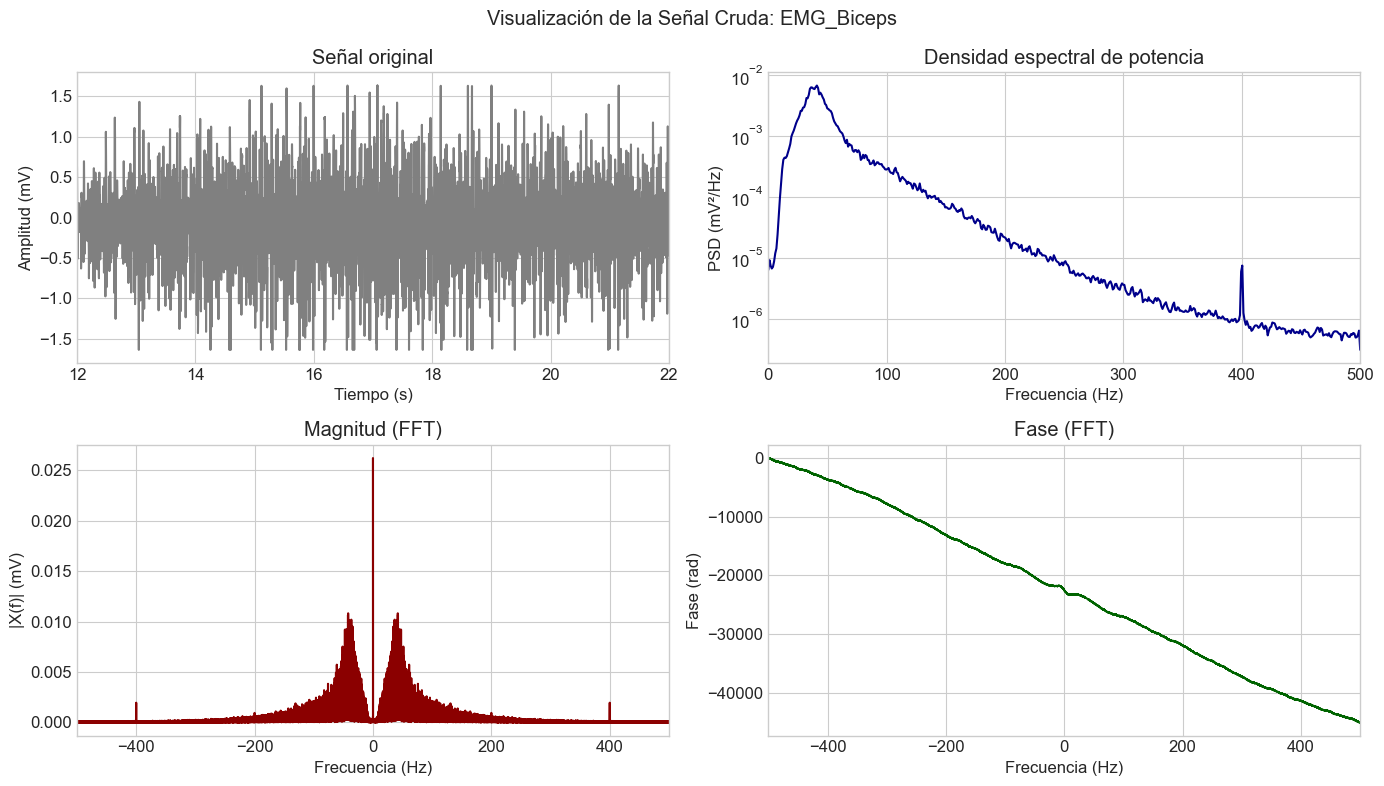

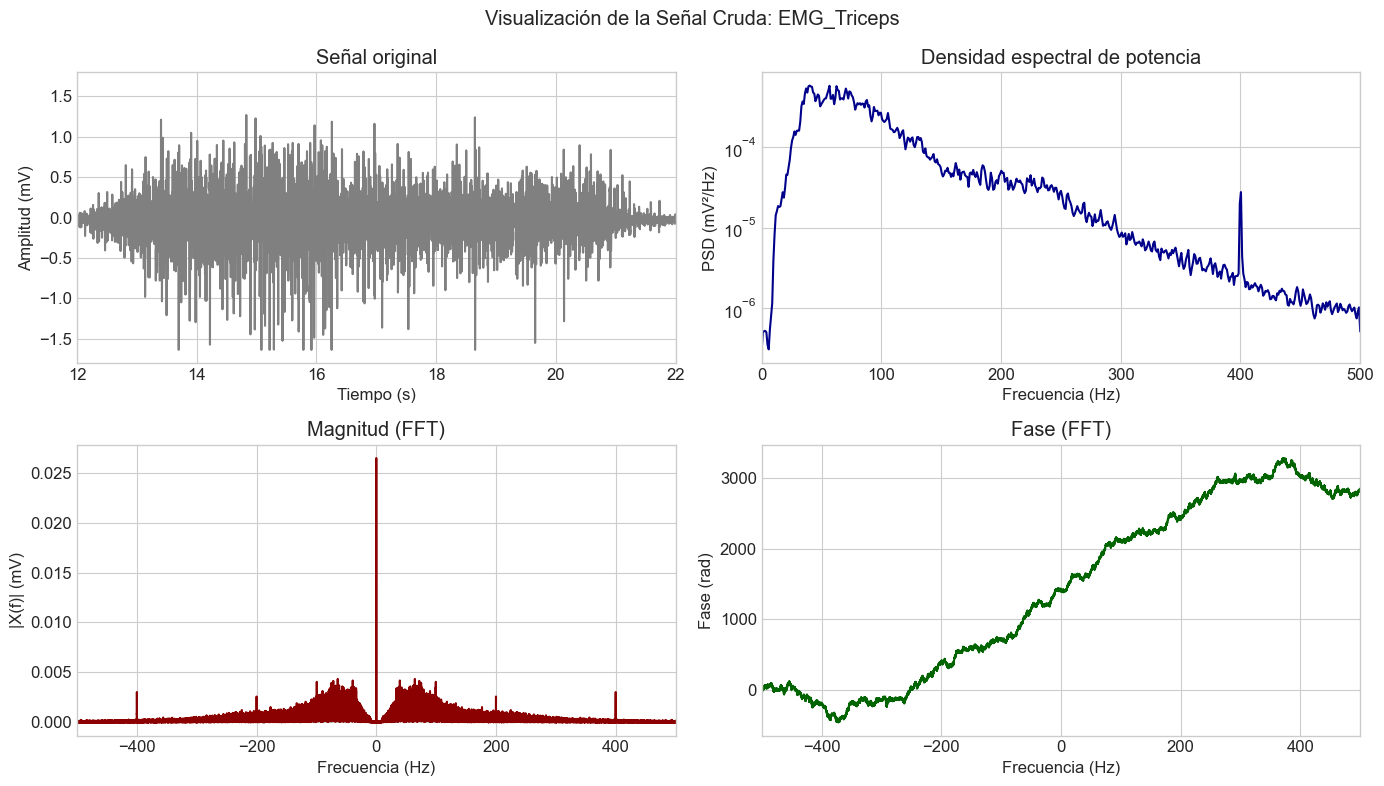

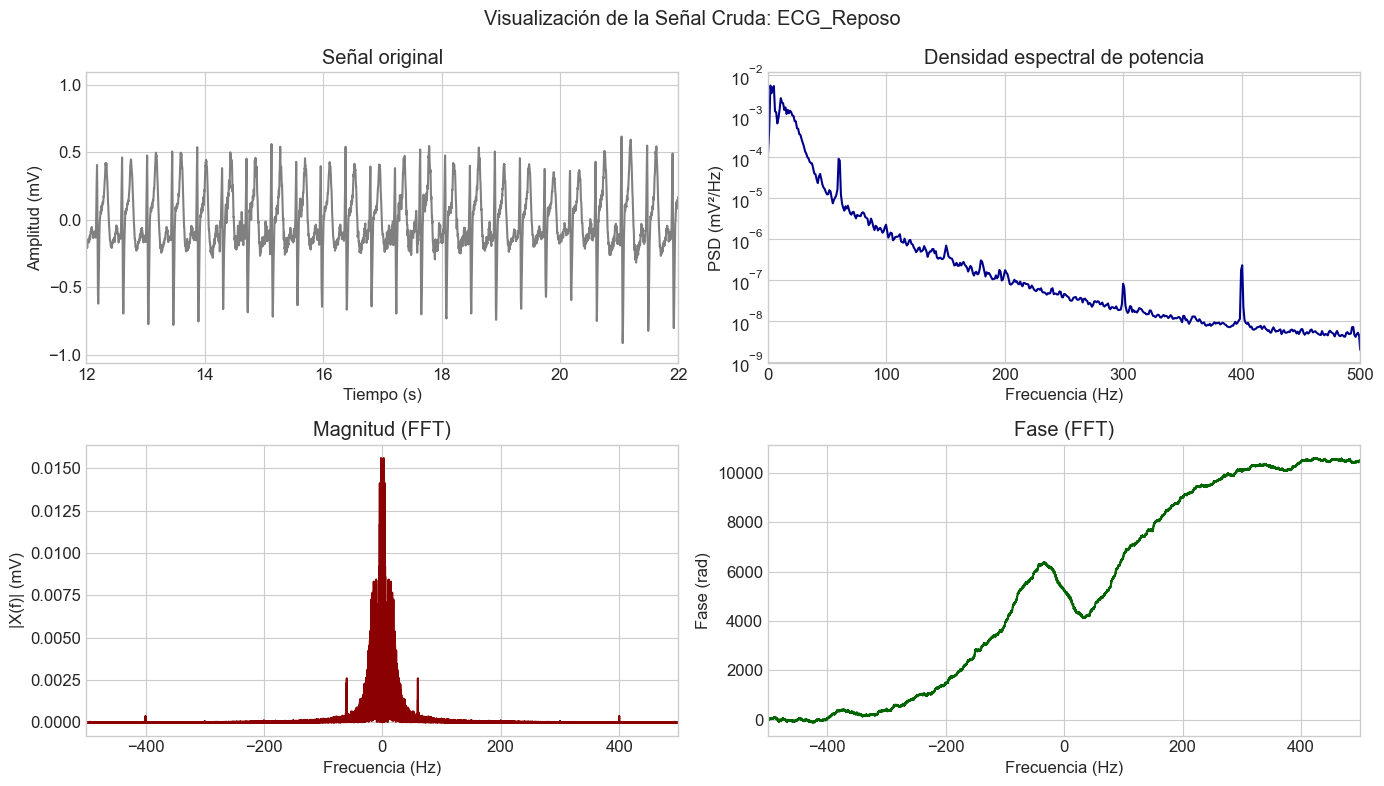

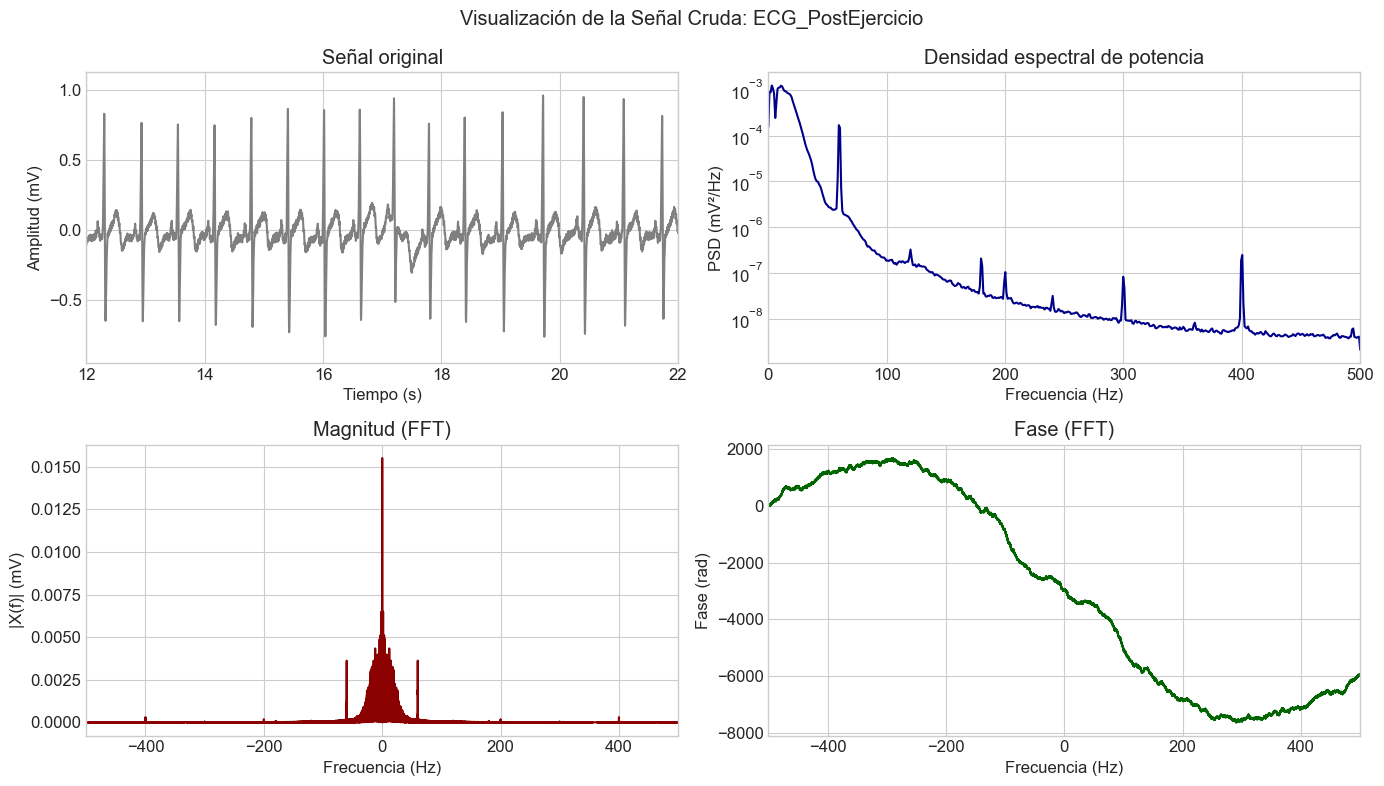

In [5]:
# 5. Visualización de Señales Crudas
for nombre, datos in SEÑALES_CRUDAS.items():
    senal = datos['senal_mv']
    tiempo = datos['tiempo']

    fig, axs = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(f'Visualización de la Señal Cruda: {nombre}')
    axs = axs.ravel()

    # Señal original
    axs[0].plot(tiempo, senal, color='gray')
    axs[0].set_title('Señal original')
    axs[0].set_xlabel('Tiempo (s)')
    axs[0].set_ylabel('Amplitud (mV)')
    axs[0].grid(True)
    axs[0].set_xlim(12, 22)

    # PSD (Welch)
    f, psd = welch(senal, fs=Fs, nperseg=1024)
    axs[1].semilogy(f, psd, color='darkblue')
    axs[1].set_title('Densidad espectral de potencia')
    axs[1].set_xlabel('Frecuencia (Hz)')
    axs[1].set_ylabel('PSD (mV²/Hz)')
    axs[1].grid(True)
    axs[1].set_xlim(0, Fs/2)

    # FFT con normalización y centrado
    N = len(senal)
    fft_vals = np.fft.fftshift(np.fft.fft(senal))
    fft_freq = np.fft.fftshift(np.fft.fftfreq(N, d=1/Fs))

    # Magnitud
    axs[2].plot(fft_freq, np.abs(fft_vals) / N, color='darkred')
    axs[2].set_title('Magnitud (FFT)')
    axs[2].set_xlabel('Frecuencia (Hz)')
    axs[2].set_ylabel('|X(f)| (mV)')
    axs[2].grid(True)
    axs[2].set_xlim(-Fs/2, Fs/2)

    # Fase (unwrapped)
    fase = np.unwrap(np.angle(fft_vals))
    axs[3].plot(fft_freq, fase, color='darkgreen')
    axs[3].set_title('Fase (FFT)')
    axs[3].set_xlabel('Frecuencia (Hz)')
    axs[3].set_ylabel('Fase (rad)')
    axs[3].grid(True)
    axs[3].set_xlim(-Fs/2, Fs/2)

    plt.tight_layout()
    plt.show()


## 3) Diseño y Análisis de Filtros para las señales
---

El análisis de las señales crudas en los dominios del tiempo y la frecuencia, como se muestra en las gráficas generadas anteriormente, revela la presencia de ruido y artefactos significativos que deben ser eliminados. A continuación, se justifica la estrategia de filtrado para cada tipo de señal basándose en esta evidencia visual.

### 3.1) Análisis y Estrategia de Filtrado para Señales EMG

Observando las gráficas de `EMG_Biceps` y `EMG_Triceps`, podemos identificar dos problemas principales:

1.  **Ruido de Baja Frecuencia (Deriva de Línea Base):** El Espectro de Densidad de Potencia (PSD) muestra una concentración muy alta de energía en las frecuencias más bajas (cercanas a 0 Hz). Este pico es la manifestación de los **artefactos de movimiento** y la **deriva de la línea base**, que, aunque no son tan obvios en el corto segmento de tiempo visualizado, contaminan la señal globalmente y afectan el cálculo de métricas como el RMS.

2.  **Ruido de Alta Frecuencia:** Por encima de los 300-400 Hz, la potencia de la señal disminuye considerablemente, pero no desaparece. Esta energía residual corresponde a **ruido electrónico** del sistema de adquisición y otras interferencias ambientales que no son de origen fisiológico.

La literatura científica, y las propias gráficas lo confirman, indica que la mayor parte de la energía útil de la señal sEMG se encuentra en la banda de **20 Hz a 450 Hz** [4].

**Estrategia de Filtrado Propuesta:**
El filtro ideal es un **Filtro Pasa-Banda (Bandpass)**. Este filtro deberá cumplir dos funciones:
-   **Atenuar las bajas frecuencias (< 20 Hz)** para eliminar la deriva de la línea base y los artefactos de movimiento.
-   **Atenuar las altas frecuencias (> 450 Hz)** para eliminar el ruido electrónico sin afectar la señal muscular.

### 3.2) Análisis y Estrategia de Filtrado para Señales ECG

El análisis de las señales `ECG_Reposo` y `ECG_PostEjercicio` revela un conjunto diferente de desafíos:

1.  **Deriva de la Línea Base (Baseline Wander):** Este es el problema más evidente. En el dominio del tiempo, se observa cómo los complejos QRS "flotan" sobre una onda lenta. En el dominio de la frecuencia (PSD), esto se confirma con un pico de potencia extremadamente grande en frecuencias muy bajas, **por debajo de 1 Hz**. Este artefacto es comúnmente causado por la respiración del sujeto y debe ser eliminado para un análisis morfológico y de ritmo preciso.

2.  **Ruido de Alta Frecuencia:** Se observa un "piso" de ruido a lo largo de las altas frecuencias. Este ruido puede provenir de la contracción de músculos cercanos (**artefacto EMG**) y de la interferencia de la red eléctrica (un pequeño pico puede ser visible cerca de los 60 Hz, aunque no sea dominante en estas capturas).

La información clínicamente relevante del ECG, especialmente la morfología del complejo P-QRS-T, se encuentra principalmente en el rango de **0.5 Hz a 40 Hz** [5]. Un filtro que preserve este rango asegurará que no distorsionemos las características diagnósticas de la señal.

**Estrategia de Filtrado Propuesta:**
La estrategia de filtrado para el ECG también será un **Filtro Pasa-Banda (Bandpass)**, pero con frecuencias de corte muy diferentes a las de EMG:
-   **Atenuar las frecuencias muy bajas (< 0.5 Hz)** para corregir la severa deriva de la línea base.
-   **Atenuar las frecuencias altas (> 40 Hz)** para reducir el ruido muscular (EMG) y electrónico, mejorando la claridad de las ondas P y T.


---
### 3.3) Diseño de Filtros EMG en `pyfdax`
---

Ahora que hemos justificado la necesidad de los filtros, procederemos a diseñar los **cuatro filtros de comparación para la señal EMG**.

#### **Filtros EMG a Diseñar**

| **Filtro** | **Tipo de Respuesta** | **Tipo / Método de Diseño** | **Fs (Hz)** | **Frecuencias (Hz)** | **Magnitud (dB)** | **Orden (si aplica)** | **Archivo de Exportación** |
|-------------|----------------------|-----------------------------|--------------|----------------------|-------------------|------------------------|-----------------------------|
| **EMG 1 (Objetivo)** | Pasa-Banda | FIR – Equiripple | 1000 | Fstop1: 10<br>Fpass1: 20<br>Fpass2: 450<br>Fstop2: 460 | Apass: 1<br>Astop: 60 | — | `emg_fir_bandpass.csv` |
| **EMG 2 (Comparativo)** | Pasa-Banda | IIR – Butterworth | 1000 | Fpass1: 20<br>Fpass2: 450 | — | 4 | `emg_iir_bandpass.csv` |
| **EMG 3 (Comparativo)** | Pasa-Bajo | FIR – Equiripple | 1000 | Fpass: 450<br>Fstop: 460 | Apass: 1<br>Astop: 60 | — | `emg_fir_lowpass.csv` |
| **EMG 4 (Comparativo)** | Pasa-Alto | FIR – Equiripple | 1000 | Fstop: 10<br>Fpass: 20 | Apass: 1<br>Astop: 60 | — | `emg_fir_highpass.csv` |

---


### 3.4) Carga y Visualización de la Respuesta en Frecuencia de los Filtros EMG

El primer paso para validar nuestro diseño es cargar los coeficientes exportados desde `pyfdax` y graficar la respuesta en frecuencia de cada filtro. Esto nos permite confirmar visualmente que las bandas de paso, las bandas de atenuación y el rizado coinciden con nuestras especificaciones de diseño.

Generaremos una gráfica de **Magnitud (en dB)** y **Fase** para cada uno de los cuatro filtros diseñados, presentadas lado a lado para una mejor comparación. En la gráfica de magnitud, incluiremos líneas de referencia en -1 dB y -60 dB para verificar rápidamente el cumplimiento de los requisitos de diseño.

--- Cargando y Visualizando Filtros EMG (Versión Final) ---
- Coeficientes para 'FIR Pasa-Banda (Objetivo)' cargados.


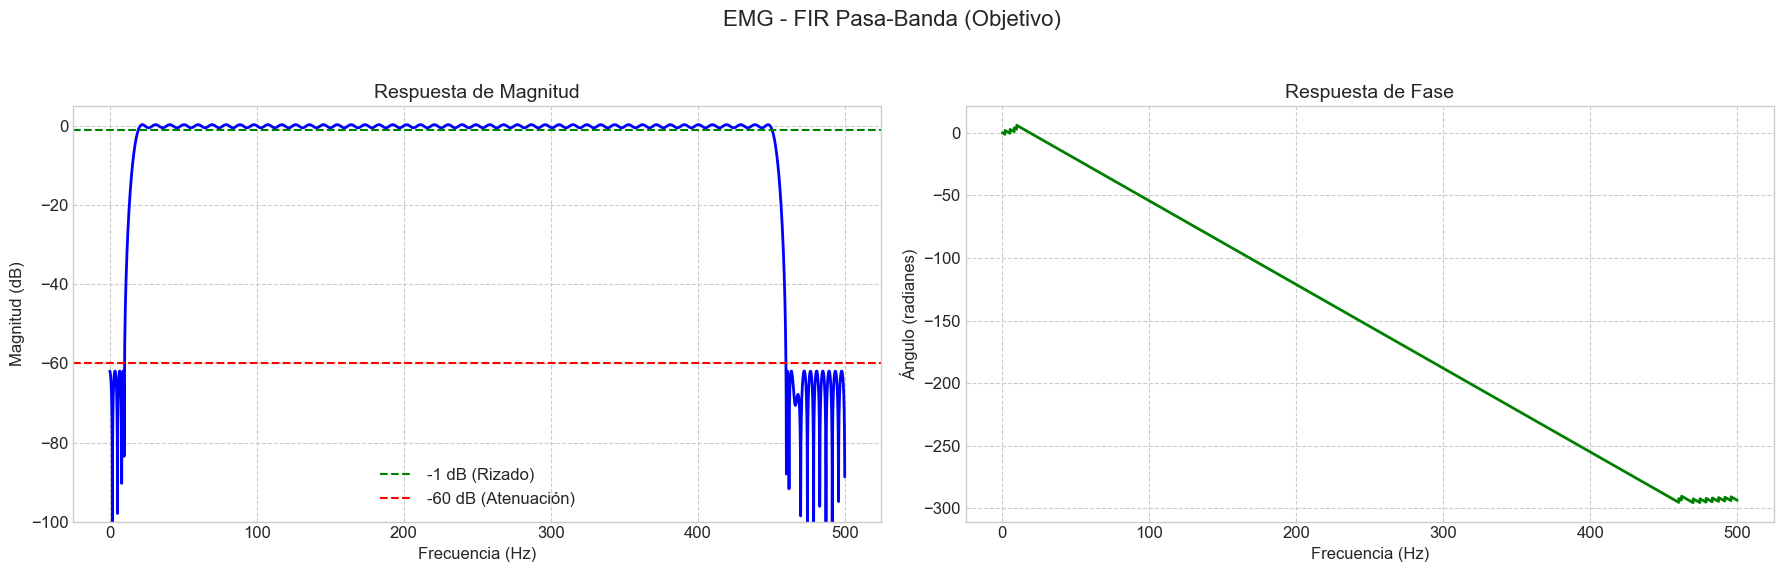

- Coeficientes para 'IIR Pasa-Banda (Butterworth)' cargados.


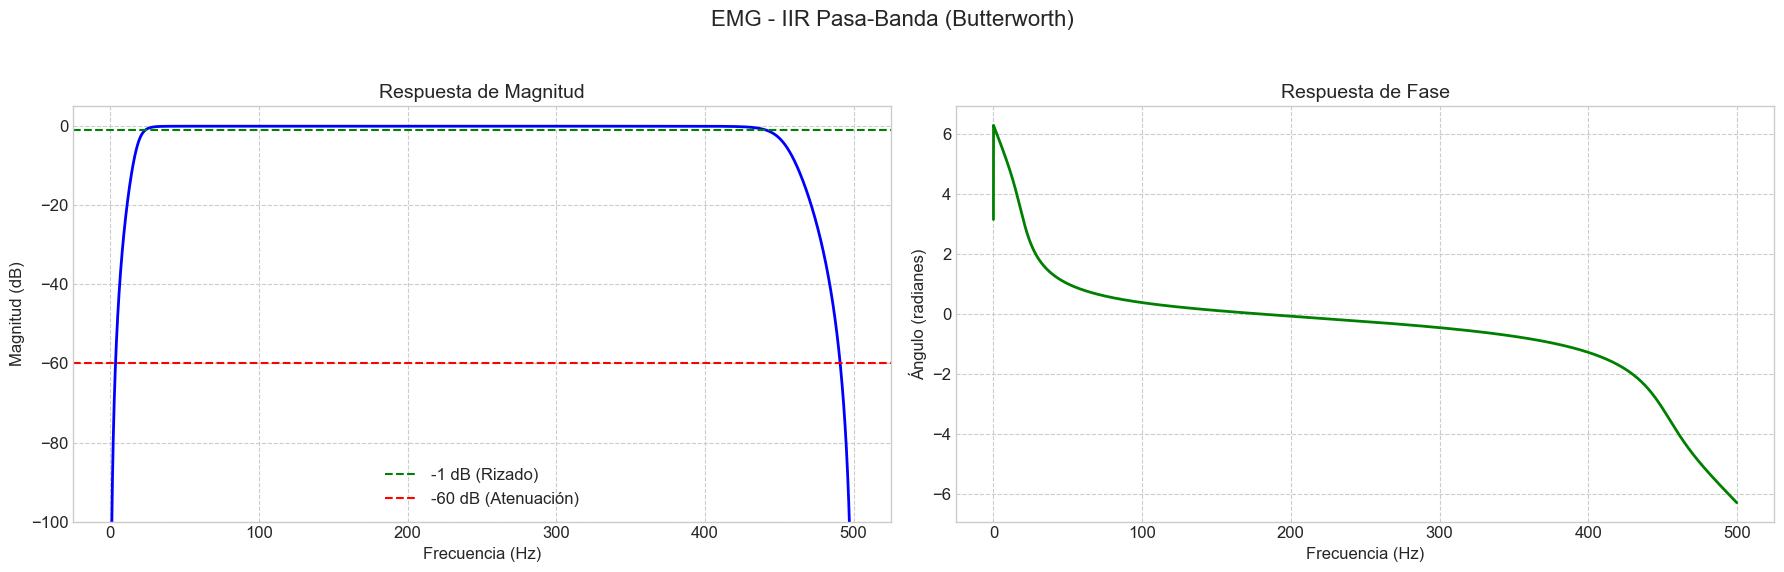

- Coeficientes para 'FIR Pasa-Bajo' cargados.


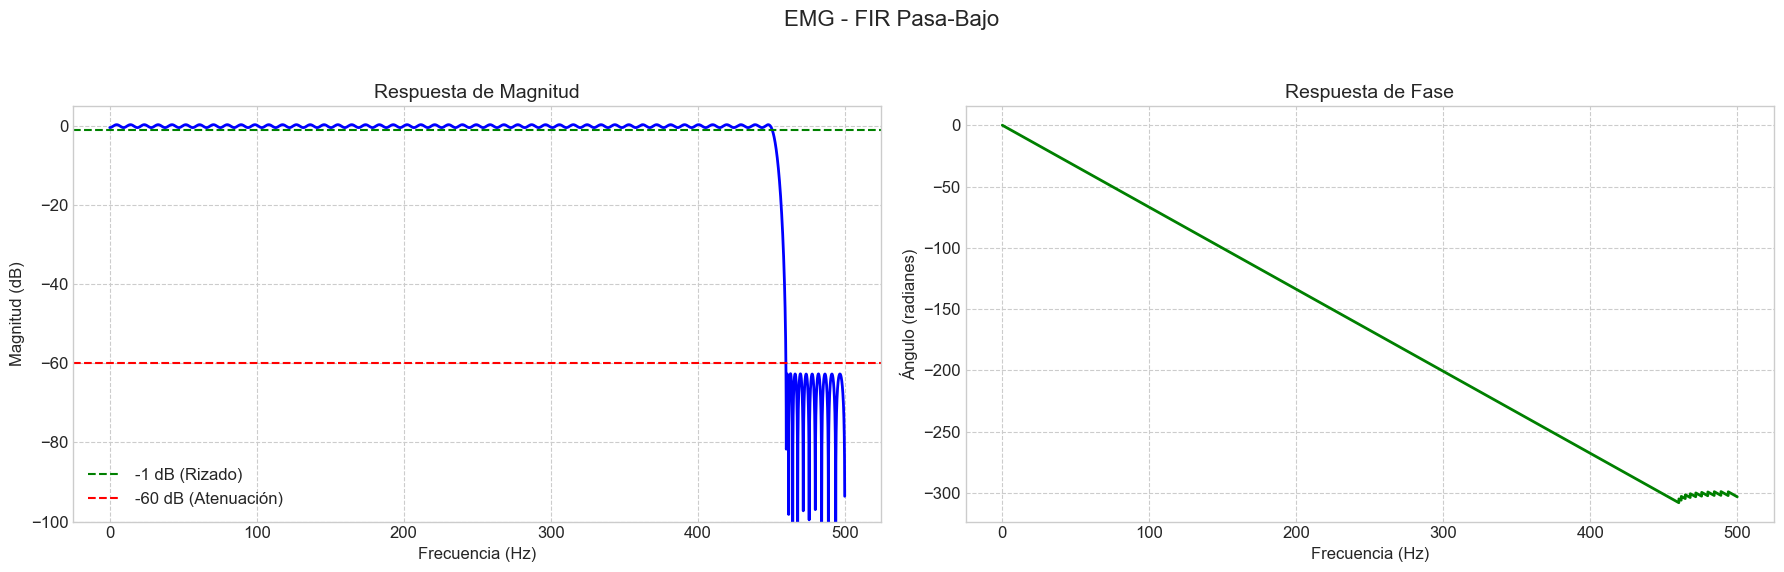

- Coeficientes para 'FIR Pasa-Alto' cargados.


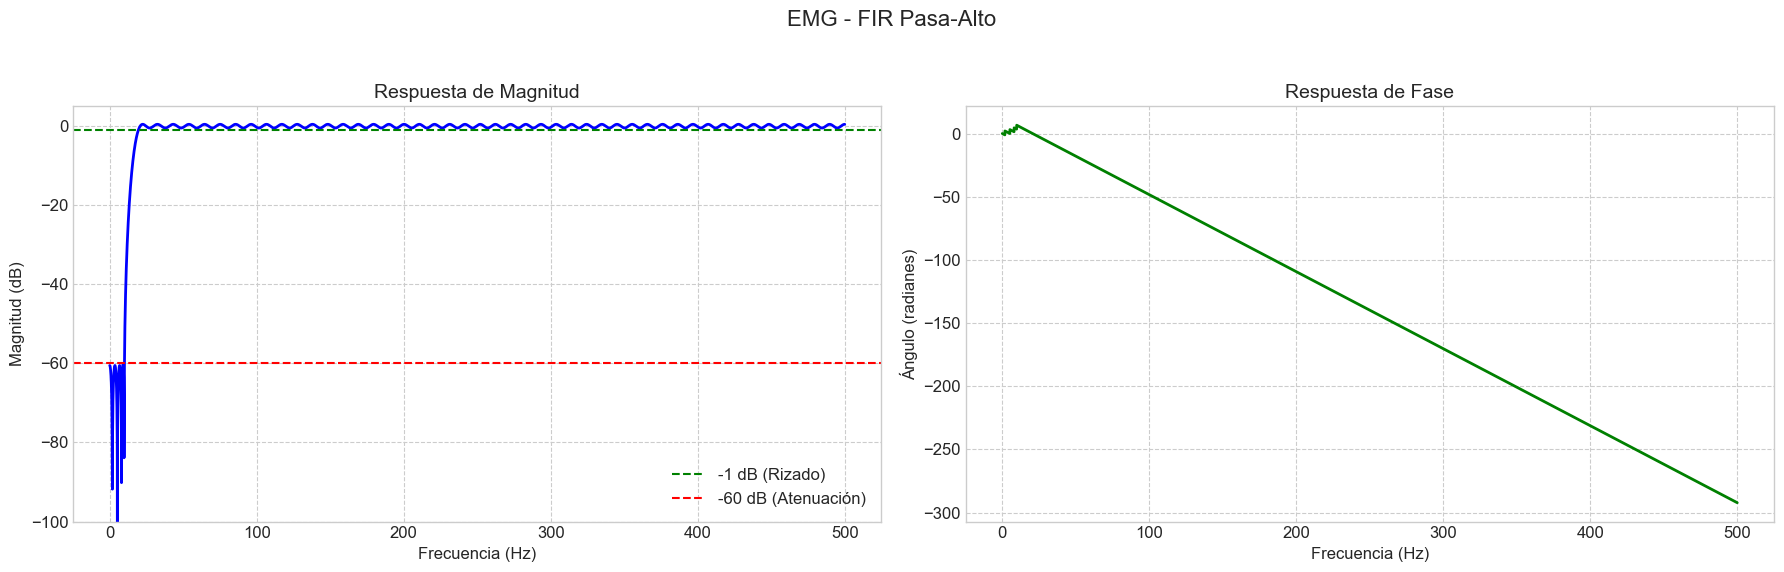

In [6]:
# Carga y Visualización de los filtros
# ------------------
# 1. DEFINICIONES DE FUNCIONES

COEF_DIR = 'Filtros_Pfyda'

def cargar_coeficientes_final(filepath):
    # Los cargaremos con np.loadtxt dado que no tienen cabeceras.
    try:
        # Carga el archivo como un array.
        # ndmin=2 asegura que la salida sea siempre 2D para un manejo consistente.
        data = np.loadtxt(filepath, delimiter=',', ndmin=2)
        
        if data.shape[1] == 1:  # Caso FIR (una sola columna)
            b = data[:, 0]
            a = np.array([1.0])
        else:  # Caso IIR (dos columnas)
            b = data[:, 0]
            a = data[:, 1]
        return b, a
    except FileNotFoundError:
        print(f"Error: No se encontró el archivo de coeficientes en '{filepath}'.")
        return None, None
    except Exception as e:
        print(f"Error al leer el archivo '{filepath}': {e}")
        return None, None

def plot_respuesta_filtro_unificada(b, a, fs, title, is_iir=False):
    # Función para graficar los filtros
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle(title, fontsize=16)

    # --- Cálculo de la Respuesta en Frecuencia ---
    if is_iir:
        # Convertir b/a a SOS para estabilidad numérica antes de graficar
        sos = tf2sos(b, a)
        w, h = sosfreqz(sos, worN=8000, fs=fs)
    else:
        w, h = freqz(b, a, worN=8000, fs=fs)
        
    # --- Subplot Izquierdo: Magnitud en dB ---
    ax1.plot(w, 20 * np.log10(np.abs(h) + 1e-9), 'b', linewidth=2)
    ax1.set_title('Respuesta de Magnitud', fontsize=14)
    ax1.set_ylabel('Magnitud (dB)', fontsize=12)
    ax1.set_xlabel('Frecuencia (Hz)', fontsize=12)
    ax1.grid(True, which='both', linestyle='--')
    ax1.axhline(-1, color='green', linestyle='--', label='-1 dB (Rizado)')
    ax1.axhline(-60, color='red', linestyle='--', label='-60 dB (Atenuación)')
    ax1.set_ylim(-100, 5)
    ax1.legend()
    
    # --- Subplot Derecho: Fase ---
    angles = np.unwrap(np.angle(h))
    ax2.plot(w, angles, 'g', linewidth=2)
    ax2.set_title('Respuesta de Fase', fontsize=14)
    ax2.set_ylabel('Ángulo (radianes)', fontsize=12)
    ax2.set_xlabel('Frecuencia (Hz)', fontsize=12)
    ax2.grid(True, which='both', linestyle='--')
    
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    img_save_path = os.path.join('imagenes', f'filtro_{title.replace(" ", "_")}.png')
    plt.savefig(img_save_path, dpi=300)
    plt.show()

# 2. Muestra para cada filtro

FILTROS_EMG_PATHS = {
    'FIR Pasa-Banda (Objetivo)': os.path.join(COEF_DIR, 'emg_fir_bandpass.csv'),
    'IIR Pasa-Banda (Butterworth)': os.path.join(COEF_DIR, 'emg_iir_bandpass.csv'),
    'FIR Pasa-Bajo': os.path.join(COEF_DIR, 'emg_fir_lowpass.csv'),
    'FIR Pasa-Alto': os.path.join(COEF_DIR, 'emg_fir_highpass.csv')
}
COEFICIENTES_EMG = {}

print("--- Cargando y Visualizando Filtros EMG (Versión Final) ---")
for nombre, ruta in FILTROS_EMG_PATHS.items():
    b, a = cargar_coeficientes_final(ruta)
    if b is not None:
        COEFICIENTES_EMG[nombre] = {'b': b, 'a': a}
        print(f"- Coeficientes para '{nombre}' cargados.")
        is_iir_flag = 'IIR' in nombre
        plot_respuesta_filtro_unificada(b, a, Fs, f'EMG - {nombre}', is_iir=is_iir_flag)

### 3.5. Aplicación y Comparación Visual de los Filtros en la Señal EMG

Una vez validados los diseños, el siguiente paso es aplicar cada filtro a las señales EMG crudas del bíceps y triceps. Esto nos permitirá observar directamente el efecto de cada uno en el dominio del tiempo y entender las consecuencias prácticas de cada elección de diseño.

Para la aplicación del filtro, utilizaremos funciones de la librería SciPy que aseguran un **filtrado de fase cero**. Esto es crucial en el análisis de señales biomédicas, ya que evita introducir retardos o distorsiones temporales en la señal, preservando la alineación temporal de eventos como el inicio de una contracción muscular [6]. Específicamente:

-   **Para filtros FIR**, usaremos `filtfilt`, que aplica el filtro una vez hacia adelante y otra hacia atrás.
-   **Para filtros IIR**, usaremos `sosfiltfilt`, que hace lo mismo pero con el formato de Secciones de Segundo Orden (SOS) para garantizar la estabilidad numérica durante la aplicación.

A continuación, se muestran segmentos de las señales EMG originales superpuestas con las cuatro versiones filtradas para una comparación directa.


--- Aplicando filtros a la señal EMG del Bíceps ---
  - Filtro FIR 'FIR Pasa-Banda (Objetivo)' aplicado usando filtfilt.
  - Filtro IIR 'IIR Pasa-Banda (Butterworth)' aplicado usando sosfiltfilt.
  - Filtro FIR 'FIR Pasa-Bajo' aplicado usando filtfilt.
  - Filtro FIR 'FIR Pasa-Alto' aplicado usando filtfilt.


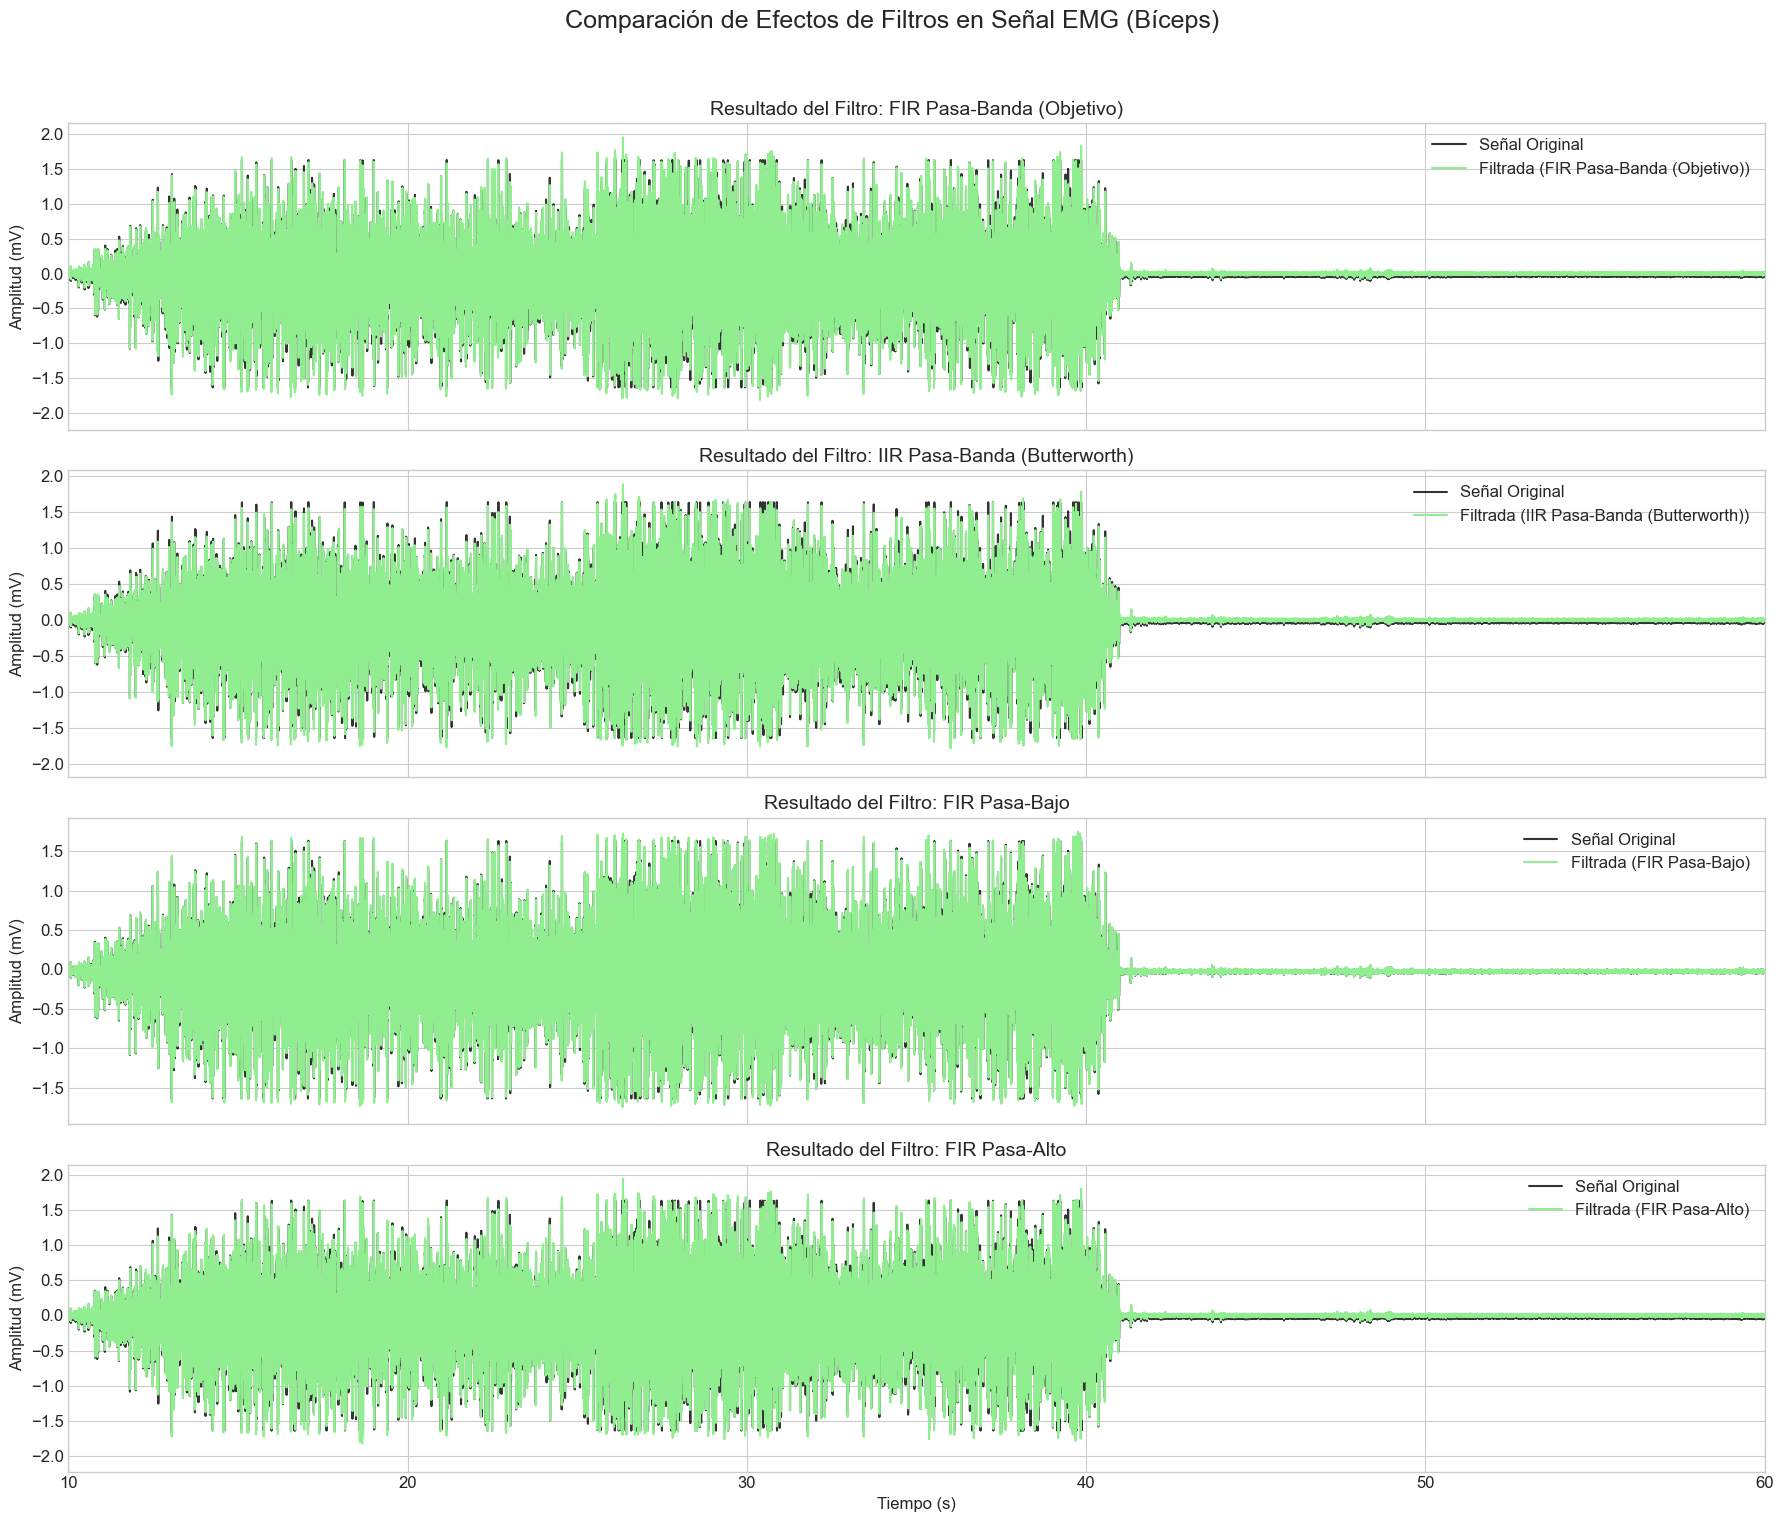

In [8]:
# -*- coding: utf-8 -*-
# ------------------
# Celda 13: Aplicar y Comparar Filtros en la Señal EMG
# ------------------
from scipy.signal import filtfilt, sosfiltfilt, tf2sos

# Seleccionar la señal de bíceps como nuestro caso de prueba
senal_original_emg = SEÑALES_CRUDAS['EMG_Biceps']['senal_mv']
tiempo_emg = SEÑALES_CRUDAS['EMG_Biceps']['tiempo']

# Diccionario para almacenar las señales después de ser filtradas
SEÑALES_FILTRADAS_EMG = {}

print("--- Aplicando filtros a la señal EMG del Bíceps ---")
for nombre, coefs in COEFICIENTES_EMG.items():
    if 'IIR' in nombre:
        # Para filtros IIR, convertimos b/a a SOS y usamos sosfiltfilt para estabilidad
        b, a = coefs['b'], coefs['a']
        sos = tf2sos(b, a)
        senal_filtrada = sosfiltfilt(sos, senal_original_emg)
        print(f"  - Filtro IIR '{nombre}' aplicado usando sosfiltfilt.")
    else:
        # Para filtros FIR, usamos filtfilt directamente
        b, a = coefs['b'], coefs['a']
        senal_filtrada = filtfilt(b, a, senal_original_emg)
        print(f"  - Filtro FIR '{nombre}' aplicado usando filtfilt.")
        
    SEÑALES_FILTRADAS_EMG[nombre] = senal_filtrada

# --- Visualización Comparativa ---
# Crear una figura con 4 subplots, uno para cada filtro
fig, axes = plt.subplots(4, 1, figsize=(18, 16), sharex=True)
fig.suptitle('Comparación de Efectos de Filtros en Señal EMG (Bíceps)', fontsize=18)

# Seleccionar un segmento de interés para visualizar (p. ej., una contracción)
# Basado en el protocolo del Lab 3, una contracción fuerte empieza alrededor de los 25s
inicio_segundo = 10
fin_segundo = 60

for i, (nombre, senal_filtrada) in enumerate(SEÑALES_FILTRADAS_EMG.items()):
    ax = axes[i]
    # Graficar la señal original en gris claro como referencia
    ax.plot(tiempo_emg, senal_original_emg, color='black', alpha=0.8, label='Señal Original')
    # Graficar la señal filtrada
    ax.plot(tiempo_emg, senal_filtrada, color ='lightgreen', label=f'Filtrada ({nombre})', linewidth=1.5)
    ax.set_title(f'Resultado del Filtro: {nombre}', fontsize=14)
    ax.set_ylabel('Amplitud (mV)', fontsize=12)
    ax.legend(loc='upper right')
    ax.set_xlim(inicio_segundo, fin_segundo)
    ax.grid(True)

axes[-1].set_xlabel('Tiempo (s)', fontsize=12)
fig.tight_layout(rect=[0, 0.03, 1, 0.96])
